## part1 天猫订单数据集

### 1.数据预处理

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
data = pd.read_csv('tmall_order_report.csv')
data.info()
# 订单创建、付款时间数量不同说明用户由于一些原因仅下单但未完成付款，这是需要挖掘的部分
# 退款金额说明用户收货后由于某些原因要求退货商家返回的金额

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28010 entries, 0 to 28009
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   订单编号      28010 non-null  int64  
 1   总金额       28010 non-null  float64
 2   买家实际支付金额  28010 non-null  float64
 3   收货地址      28010 non-null  object 
 4   订单创建时间    28010 non-null  object 
 5   订单付款时间    24087 non-null  object 
 6   退款金额      28010 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.5+ MB


In [3]:
# 检查列名是否存在空值
for col in data.columns:
    print(f"'{col}'")

# 处理列名空值
data.columns = data.columns.str.strip()
data.columns

'订单编号'
'总金额'
'买家实际支付金额'
'收货地址 '
'订单创建时间'
'订单付款时间 '
'退款金额'


Index(['订单编号', '总金额', '买家实际支付金额', '收货地址', '订单创建时间', '订单付款时间', '退款金额'], dtype='object')

In [4]:
# 检查是否有完全重复的行
data[data.duplicated()].count()

订单编号        0
总金额         0
买家实际支付金额    0
收货地址        0
订单创建时间      0
订单付款时间      0
退款金额        0
dtype: int64

In [5]:
# 清洗收货地址，把后缀词去掉，只保留省份名或城市名
data['收货地址'].unique()
data['收货地址'] = data['收货地址'].str.replace('自治区|维吾尔|回族|壮族|省','',regex=True)
data['收货地址'].unique()

array(['上海', '内蒙古', '安徽', '湖南', '江苏', '浙江', '天津', '北京', '四川', '贵州', '辽宁',
       '河南', '广西', '广东', '福建', '海南', '江西', '甘肃', '河北', '黑龙江', '云南', '重庆',
       '山西', '吉林', '山东', '陕西', '湖北', '青海', '新疆', '宁夏', '西藏'], dtype=object)

### 2.数据分析可视化
#### 2.1整体情况

In [6]:
# 创建一个字典统计订单核心指标
result = {}
result['总订单数'] = data['订单编号'].count()
result['已完成订单数'] = data['订单编号'][data['订单付款时间'].notnull()].count()
result['未付款订单数'] = data['订单编号'][data['订单付款时间'].isnull()].count()
result['退款订单数'] = data['订单编号'][data['退款金额']>0].count()
result['总订单金额'] = data['总金额'][data['订单付款时间'].notnull()].sum()
result['总退款金额'] = data['退款金额'][data['订单付款时间'].notnull()].sum()
result['总实际收入金额'] = data['买家实际支付金额'][data['订单付款时间'].notnull()].sum()
result

{'总订单数': 28010,
 '已完成订单数': 24087,
 '未付款订单数': 3923,
 '退款订单数': 5646,
 '总订单金额': 2474823.0700000003,
 '总退款金额': 572335.9199999999,
 '总实际收入金额': 1902487.1500000001}

In [7]:
from pyecharts import options as opts
from pyecharts.charts import Map,Bar,Line
from pyecharts.components import Table
from pyecharts.options import ComponentTitleOpts
from pyecharts.faker import Faker

In [8]:
table = Table()
headers = ['总订单数','总订单金额','已完成订单数','总实际收入金额','退款订单数','总退款金额','成交率','退货率']
rows = [
    [
        result['总订单数'],
        f"{result['总订单金额']/10000:.2f} 万",
        result['已完成订单数'],
        f"{result['总实际收入金额']/10000:.2f} 万",
        result['退款订单数'],
        f"{result['总退款金额']/10000:.2f} 万",
        f"{result['已完成订单数']/result['总订单数']:.2%}",
        f"{result['退款订单数']/result['已完成订单数']:.2%}"
    ]
]
table.add(headers, rows)
table.set_global_opts(
    title_opts=ComponentTitleOpts(title='整体情况')
)
table.render_notebook()

总订单数,总订单金额,已完成订单数,总实际收入金额,退款订单数,总退款金额,成交率,退货率
28010,247.48 万,24087,190.25 万,5646,57.23 万,85.99%,23.44%


#### 2.2地区分析

In [9]:
result_2 = data[data['订单付款时间'].notnull()].groupby('收货地址').agg({'订单编号':'count'})
result_2_1 = result_2.to_dict()['订单编号']
c = (
    Map()
    .add("订单量", [*result_2_1.items()], "china", is_map_symbol_show=False)
    .set_series_opts(label_opts=opts.LabelOpts(is_show=True))
    .set_global_opts(
        title_opts=opts.TitleOpts(title='地区分布'),
        visualmap_opts=opts.VisualMapOpts(max_=1000),            
    )
)

c.render_notebook()

#### 2.3时间分析

In [10]:
data['订单创建时间'] = pd.to_datetime(data['订单创建时间'])
data['订单付款时间'] = pd.to_datetime(data['订单付款时间'])

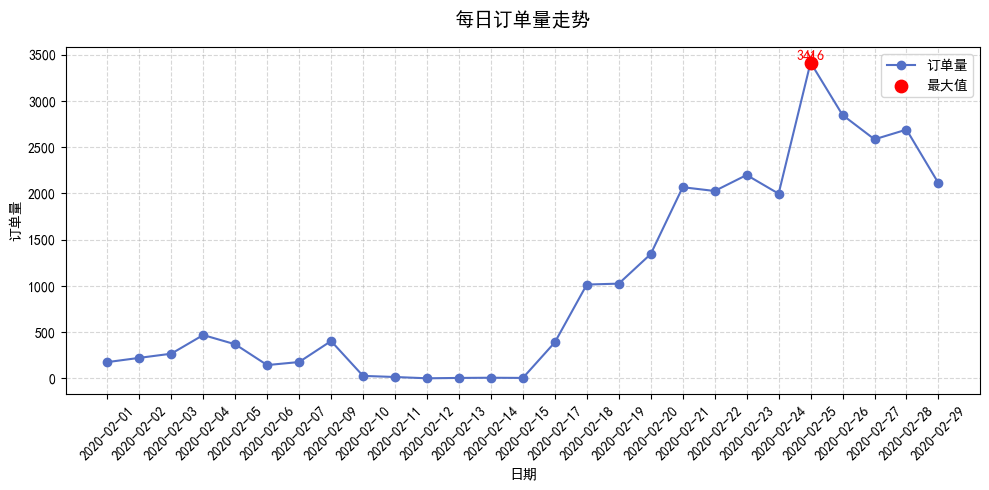

In [11]:
result_3_1 = data.groupby(data['订单创建时间'].apply(lambda x: x.strftime("%Y-%m-%d"))).agg({'订单编号': 'count'}).to_dict()['订单编号']

# 提取日期和订单量
dates = list(result_3_1.keys())
counts = list(result_3_1.values())

# 创建图形
plt.figure(figsize=(10, 5))

# 绘制折线图
plt.plot(dates, counts, marker='o', linestyle='-', color='#5470c6', label='订单量')

# 标注最大值点
max_idx = counts.index(max(counts))  # 最大值索引
max_date = dates[max_idx]
max_value = counts[max_idx]
plt.scatter(max_date, max_value, color='red', s=80, zorder=5, label='最大值')
plt.annotate(f'{max_value}',
             xy=(max_date, max_value),
             xytext=(max_date, max_value + 5),
             arrowprops=dict(arrowstyle='->', color='red'),
             ha='center', va='bottom', color='red')

plt.title('每日订单量走势', fontsize=14, pad=15)
plt.xlabel('日期')
plt.ylabel('订单量')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 从图可知，二月上半月受新冠疫情影响订单量较少，随着开工逐渐恢复，增长明显

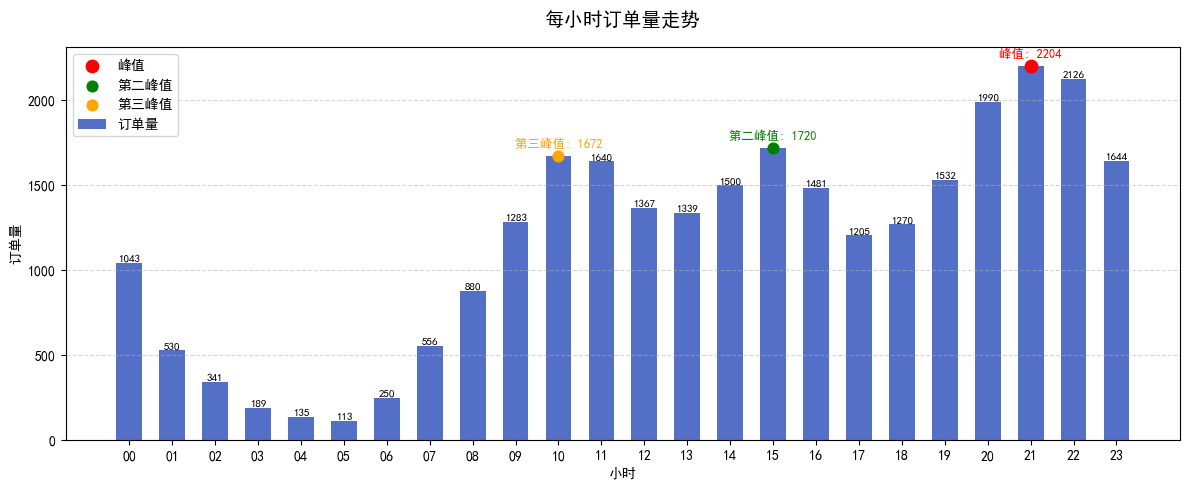

In [12]:
result_3_2 = data.groupby(data['订单创建时间'].apply(lambda x: x.strftime("%H"))).agg({'订单编号': 'count'}).to_dict()['订单编号']

x = list(result_3_2.keys())
y = list(result_3_2.values())

plt.figure(figsize=(12, 5))
bars = plt.bar(x, y, color='#5470c6', width=0.6, label='订单量')

peak_indexes = []

# 最大值索引
max_val = max(y)
max_idx = y.index(max_val)
peak_indexes.append(max_idx)
peak_indexes.append(15)
peak_indexes.append(10)

# 给柱子加标签
for i, bar in enumerate(bars):
    height = bar.get_height()
    if i in peak_indexes:
        continue
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.5,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

# 标注最大值点
plt.scatter(x[max_idx], max_val, color='red', s=80, zorder=5, label='峰值')
plt.annotate(f'峰值: {max_val}',
             xy=(x[max_idx], max_val),
             xytext=(x[max_idx], max_val + 35),  # 距离拉远
             ha='center', va='bottom', color='red', fontsize=9, fontweight='bold')

# 标注第二峰值
coord2_x = x[15]
coord2_y = y[15]
plt.scatter(coord2_x, coord2_y, color='green', s=60, zorder=5, label='第二峰值')
plt.annotate(f'第二峰值: {coord2_y}',
                 xy=(coord2_x, coord2_y),
                 xytext=(coord2_x, coord2_y + 35),
                 ha='center', va='bottom', color='green', fontsize=9)

# 标注第三峰值
coord3_x = x[10]
coord3_y = y[10]
plt.scatter(coord3_x, coord3_y, color='orange', s=60, zorder=5, label='第三峰值')
plt.annotate(f'第三峰值: {coord3_y}',
                 xy=(coord3_x, coord3_y),
                 xytext=(coord3_x, coord3_y + 35),
                 ha='center', va='bottom', color='orange', fontsize=9)

plt.title('每小时订单量走势', fontsize=14, pad=15)
plt.xlabel('小时')
plt.ylabel('订单量')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 一天中有三个高峰期（10/15/21），在软件首页推流可选择这几个时间点，并且在高峰期保证客服回复速度

In [13]:
# 从下单到付款的平均时间
s = data['订单付款时间']-data['订单创建时间']
s[s.notnull()].apply(lambda x: x.seconds / 60).mean()

7.7399046511949745

## part2 淘宝双十一某店铺数据集
### 1.数据预处理

In [14]:
data2 = pd.read_csv('双十一淘宝美妆数据.csv')
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27598 entries, 0 to 27597
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   update_time    27598 non-null  object 
 1   id             27598 non-null  object 
 2   title          27598 non-null  object 
 3   price          27598 non-null  float64
 4   sale_count     25244 non-null  float64
 5   comment_count  25244 non-null  float64
 6   店名             27598 non-null  object 
dtypes: float64(3), object(4)
memory usage: 1.5+ MB


In [15]:
# 去重
data2.drop_duplicates(inplace=True)
data2.reset_index(drop=True,inplace=True)
# 空值处理
data2.isnull().sum()
data2.fillna(0,inplace=True)

In [16]:
#处理日期格式
data2['update_time'] = pd.to_datetime(data2['update_time']).apply(lambda x: x.strftime("%Y-%m-%d"))

In [17]:
# 增加一列销售额
data2['sale_amount'] = data2['price'] * data2['sale_count']

### 2.数据分析与可视化
#### 2.1每日整体销售量走势

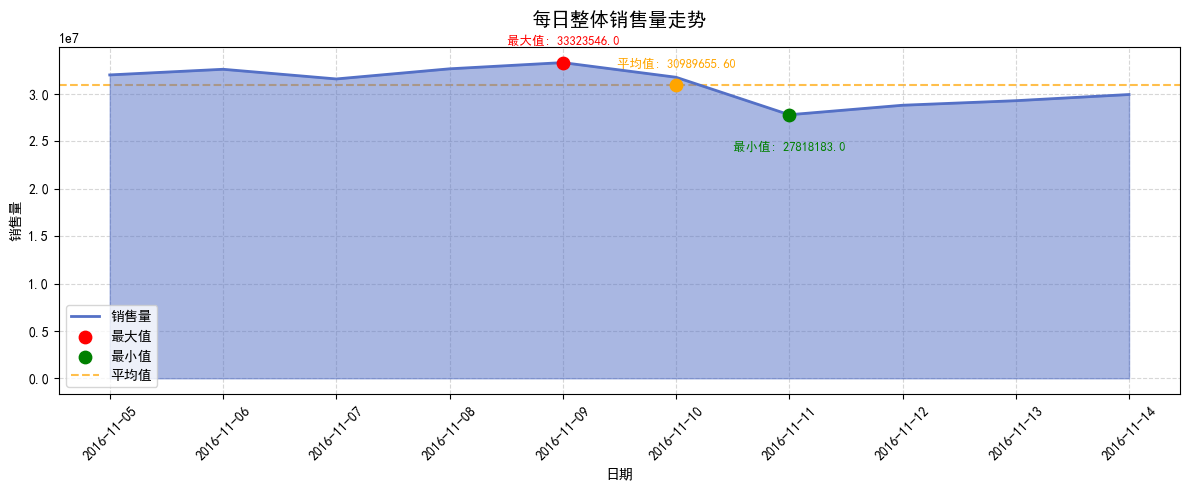

In [18]:
result = data2.groupby('update_time').agg({'sale_count': 'sum'}).to_dict()['sale_count']

dates = list(result.keys())
sales = list(result.values())

fig, ax = plt.subplots(figsize=(12, 5))
line = ax.plot(dates, sales, color='#5470c6', linewidth=2, label='销售量', zorder=3)

ax.fill_between(dates, sales, color='#5470c6', alpha=0.5, zorder=2)

# 计算统计值
max_val = max(sales)
min_val = min(sales)
avg_val = np.mean(sales)

# 获取对应日期的索引
max_idx = sales.index(max_val)
min_idx = sales.index(min_val)

# 为了平均值标记，取日期范围的中间位置作为显示位置
avg_date_idx = len(dates) // 2
avg_date = dates[avg_date_idx]

# 绘制最大值标记
ax.scatter(dates[max_idx], max_val, color='red', s=80, zorder=5, label='最大值')
ax.annotate(f'最大值: {max_val}',
            xy=(dates[max_idx], max_val),
            xytext=(dates[max_idx], max_val + max_val*0.05),
            ha='center', va='bottom', color='red', fontsize=9)

# 绘制最小值标记
ax.scatter(dates[min_idx], min_val, color='green', s=80, zorder=5, label='最小值')
ax.annotate(f'最小值: {min_val}',
            xy=(dates[min_idx], min_val),
            xytext=(dates[min_idx], min_val - min_val*0.1 if min_val > 0 else min_val*1.1),
            ha='center', va='top', color='green', fontsize=9)

# 绘制平均值标记
ax.axhline(y=avg_val, color='orange', linestyle='--', alpha=0.7, zorder=1, label='平均值')
ax.scatter(avg_date, avg_val, color='orange', s=80, zorder=5)
ax.annotate(f'平均值: {avg_val:.2f}',
            xy=(avg_date, avg_val),
            xytext=(avg_date, avg_val + avg_val*0.05),
            ha='center', va='bottom', color='orange', fontsize=9)

ax.set_title('每日整体销售量走势', fontsize=14, pad=15)
ax.set_xlabel('日期')
ax.set_ylabel('销售量')
plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
dts = list(data2['update_time'].unique())
dts.reverse()
dts

['2016-11-05',
 '2016-11-06',
 '2016-11-07',
 '2016-11-08',
 '2016-11-09',
 '2016-11-10',
 '2016-11-11',
 '2016-11-12',
 '2016-11-13',
 '2016-11-14']

#### 2.2谁家的化妆品卖的最好

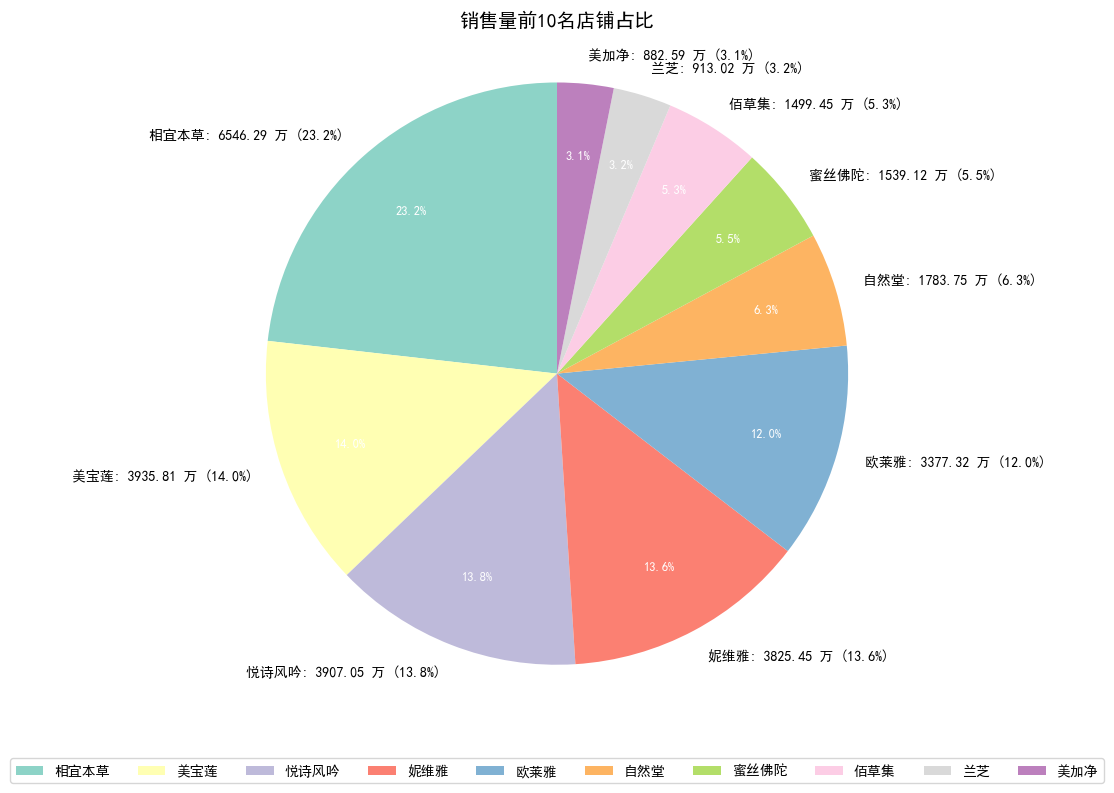

In [20]:
item = data2.groupby('店名').agg({'sale_count': 'sum'}).sort_values(by='sale_count', ascending=False)[:10].to_dict()['sale_count']

item = {k: round(v / 10000, 2) for k, v in item.items()}

labels = list(item.keys())
values = list(item.values())

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    startangle=90,
    colors=plt.cm.Set3.colors,
    pctdistance=0.75,
)

for i, (label, val, pct) in enumerate(zip(labels, values, autotexts)):
    percent = pct.get_text()
    new_label = f'{label}: {val} 万 ({percent})'
    texts[i].set_text(new_label)
    texts[i].set_fontsize(10)
    autotexts[i].set_fontsize(9)
    autotexts[i].set_color('white')
    autotexts[i].set_weight('bold')

ax.set_title('销售量前10名店铺占比', fontsize=14, pad=20)
ax.axis('equal')
ax.legend(wedges, labels,
          loc="lower center",
          bbox_to_anchor=(0.5, -0.15),
          ncol=len(labels),  # 一行显示所有图例项
          fontsize=10)
plt.tight_layout()
plt.show()

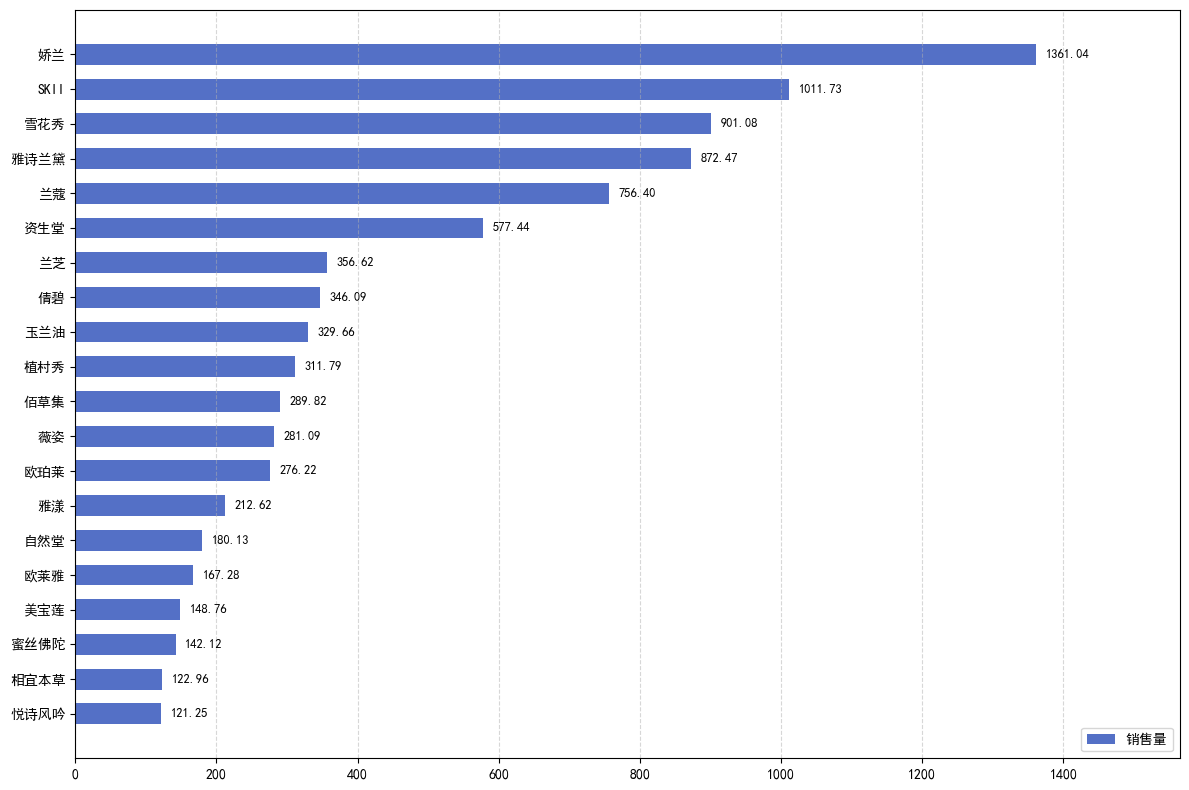

In [21]:
item = data2.groupby('店名').agg({'price': 'mean'}).sort_values(by='price', ascending=False)[:20].sort_values(by='price', ascending=True).to_dict()['price']

shops = list(item.keys())
prices = [round(v, 2) for v in item.values()]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(shops, prices, color='#5470c6', height=0.6)

for bar, price in zip(bars, prices):
    ax.text(bar.get_width() + max(prices)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{price:.2f}',
            va='center', fontsize=9)

ax.set_xlim(right=max(prices) * 1.15)
ax.legend(['销售量'], loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## part3 日化数据集
### 1.数据预处理
#### 1.1商品表数据清洗

In [22]:
fact_order = pd.read_excel('日化.xlsx', sheet_name='销售订单表')
dim_product = pd.read_excel('日化.xlsx', sheet_name='商品信息表')
fact_order.info()
dim_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31452 entries, 0 to 31451
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单编码    31452 non-null  object 
 1   订单日期    31452 non-null  object 
 2   客户编码    31452 non-null  object 
 3   所在区域    31450 non-null  object 
 4   所在省份    31450 non-null  object 
 5   所在地市    31452 non-null  object 
 6   商品编号    31451 non-null  object 
 7   订购数量    31450 non-null  object 
 8   订购单价    31448 non-null  object 
 9   金额      31448 non-null  float64
dtypes: float64(1), object(9)
memory usage: 2.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   商品编号    122 non-null    object
 1   商品名称    122 non-null    object
 2   商品小类    122 non-null    object
 3   商品大类    122 non-null    object
 4   销售单价    122 non-null    int64 
dtypes: int64(1), object(4)
memory usag

In [23]:
dim_product.describe()

,销售单价
count,122.000000
mean,156.155738
std,58.454619
min,56.000000
25%,102.250000
50%,158.000000
75%,210.750000
max,253.000000


In [24]:
dim_product[dim_product.duplicated()].count()

商品编号    0
商品名称    0
商品小类    0
商品大类    0
销售单价    0
dtype: int64

In [25]:
dim_product[dim_product['商品编号'].duplicated()].count()

商品编号    0
商品名称    0
商品小类    0
商品大类    0
销售单价    0
dtype: int64

In [26]:
dim_product.isnull().sum()

商品编号    0
商品名称    0
商品小类    0
商品大类    0
销售单价    0
dtype: int64

#### 1.2订单表数据清洗

In [27]:
fact_order[fact_order.duplicated()].count()

订单编码    6
订单日期    6
客户编码    6
所在区域    6
所在省份    6
所在地市    6
商品编号    6
订购数量    6
订购单价    6
金额      6
dtype: int64

In [28]:
fact_order.drop_duplicates(inplace=True)
fact_order.reset_index(drop=True,inplace=True)
fact_order.isnull().sum()

订单编码    0
订单日期    0
客户编码    0
所在区域    2
所在省份    2
所在地市    0
商品编号    1
订购数量    2
订购单价    4
金额      4
dtype: int64

In [29]:
fact_order.fillna(method='bfill',inplace=True)
fact_order.fillna(method='ffill',inplace=True)
fact_order.isnull().sum()

C:\Users\GJ921\AppData\Local\Temp\ipykernel_36116\2394574004.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fact_order.fillna(method='bfill',inplace=True)
C:\Users\GJ921\AppData\Local\Temp\ipykernel_36116\2394574004.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fact_order.fillna(method='ffill',inplace=True)


订单编码    0
订单日期    0
客户编码    0
所在区域    0
所在省份    0
所在地市    0
商品编号    0
订购数量    0
订购单价    0
金额      0
dtype: int64

In [31]:
fact_order['订单日期'] = fact_order['订单日期'].apply(
    lambda x: pd.to_datetime(x, errors='coerce') if isinstance(x, str) else x
)
fact_order = fact_order[fact_order['订单日期'] < '2021-01-01']
fact_order['订单日期'].max(),fact_order['订单日期'].min()

(Timestamp('2019-09-30 00:00:00'), Timestamp('2019-01-01 00:00:00'))

In [36]:
fact_order['订购数量'] = fact_order['订购数量'].apply(lambda x: x.strip('个') if isinstance(x,str) else x).astype('int')
fact_order['订购单价'] = fact_order['订购单价'].apply(lambda x: x.strip('元') if isinstance(x,str) else x).astype('float')
fact_order['金额'] = fact_order['金额'].astype('float')
fact_order.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28551 entries, 0 to 31445
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   订单编码    28551 non-null  object        
 1   订单日期    28551 non-null  datetime64[ns]
 2   客户编码    28551 non-null  object        
 3   所在区域    28551 non-null  object        
 4   所在省份    28551 non-null  object        
 5   所在地市    28551 non-null  object        
 6   商品编号    28551 non-null  object        
 7   订购数量    28551 non-null  int32         
 8   订购单价    28551 non-null  float64       
 9   金额      28551 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), object(6)
memory usage: 2.3+ MB


In [38]:
fact_order['所在省份'] = fact_order['所在省份'].str.replace('自治区|维吾尔|回族|壮族|省|市','',regex=True)
fact_order['所在省份'].unique()

array(['浙江', '安徽', '山西', '吉林', '北京', '云南', '广西', '内蒙古', '新疆', '湖北', '广东',
       '江苏', '甘肃', '四川', '河南', '福建', '辽宁', '江西', '重庆', '陕西', '湖南', '河北',
       '贵州', '上海', '山东', '天津', '海南', '宁夏', '黑龙江'], dtype=object)

In [39]:
fact_order['客户编码'] = fact_order['客户编码'].str.replace('编号','')

#### 2.1每月订购情况

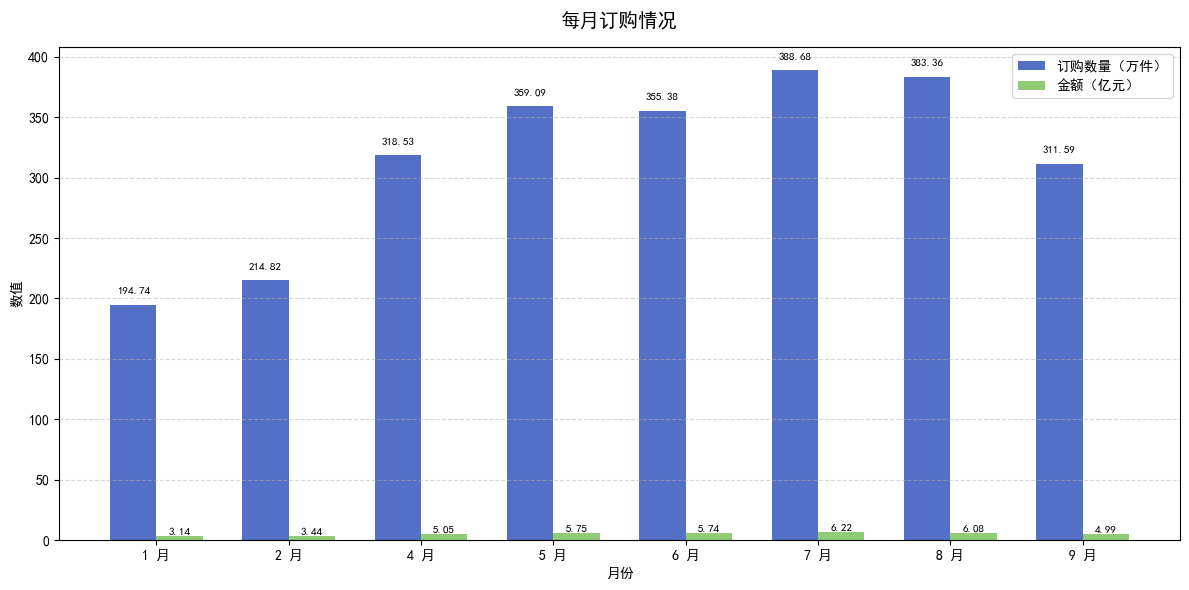

In [44]:
fact_order['订单月份'] = fact_order['订单日期'].apply(lambda x: x.month)
item = fact_order.groupby('订单月份').agg({'订购数量': 'sum', '金额': 'sum'}).to_dict()

months = sorted(item['订购数量'].keys())
x = [f'{m} 月' for m in months]
y1 = [round(val1 / 10000, 2) for val1 in (item['订购数量'][key1] for key1 in months)]  # 万件
y2 = [round(val2 / 100000000, 2) for val2 in (item['金额'][key2] for key2 in months)]  # 亿元

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(x))
width = 0.35
bars1 = ax.bar(x_pos - width/2, y1, width, label='订购数量（万件）', color='#5470c6')
bars2 = ax.bar(x_pos + width/2, y2, width, label='金额（亿元）', color='#91cc75')
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(y1),
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(y2),
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.set_xlabel('月份')
ax.set_ylabel('数值')
ax.set_title('每月订购情况', fontsize=14, pad=15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2.2哪个市的购买力最强

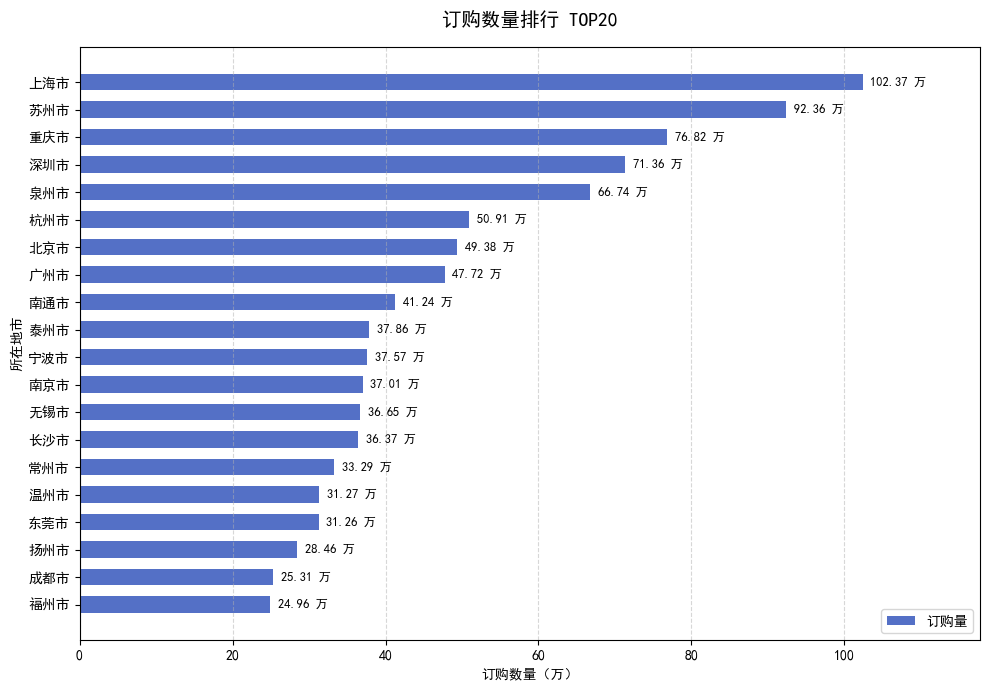

In [56]:
item = fact_order.groupby('所在地市'). \
    agg({'订购数量': 'sum'}) \
    .sort_values(by='订购数量', ascending=False)[:20] \
    .sort_values(by='订购数量', ascending=True) \
    .to_dict()['订购数量']

cities = list(item.keys())
quantities = [round(v / 10000, 2) for v in item.values()]  # 万件

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cities, quantities, color='#5470c6', height=0.6, label='订购量')

for bar, qty in zip(bars, quantities):
    ax.text(bar.get_width() + max(quantities) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{qty:.2f} 万',
            va='center', fontsize=9)

ax.set_title('订购数量排行 TOP20', fontsize=14, pad=15)
ax.set_xlabel('订购数量（万）')
ax.set_ylabel('所在地市')
ax.set_xlim(right=max(quantities) * 1.15)
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2.3哪种类型的美妆需求量最大

In [57]:
order = pd.merge(fact_order,dim_product,on='商品编号',how='inner')
order.head()

,订单编码,订单日期,客户编码,所在区域,所在省份,所在地市,商品编号,订购数量,订购单价,金额,订单月份,商品名称,商品小类,商品大类,销售单价
0,D31313,2019-05-16,S22796,东区,浙江,台州市,X091,892,214.0,190888.0,5,商品91,粉底,彩妆,214
1,D21329,2019-05-14,S11460,东区,安徽,宿州市,X005,276,185.0,51060.0,5,商品5,面膜,护肤品,185
2,D22372,2019-08-26,S11101,北区,山西,忻州市,X078,1450,116.0,168200.0,8,商品78,口红,彩妆,116
3,D31078,2019-04-08,S10902,北区,吉林,延边朝鲜族自治州,X025,1834,102.0,187068.0,4,商品25,眼霜,护肤品,102
4,D32470,2019-04-11,S18696,北区,北京,北京市,X010,887,58.0,51446.0,4,商品10,面膜,护肤品,58


In [58]:
order.groupby(['商品大类','商品小类']).agg({'订购数量':'sum'}).sort_values(by=['商品大类','订购数量'],ascending=[True,False])

订购数量
商品大类 商品小类         
彩妆   口红    1843992
     粉底    1073721
     睫毛膏    531556
     眼影     272785
     蜜粉      40797
护肤品  面膜    4925993
     面霜    4130145
     爽肤水   3232251
     眼霜    3057570
     隔离霜   2228656
     防晒霜   2175883
     洁面乳   1746929

#### 2.4通过RFM模型挖掘客户价值

In [59]:
# 设定一个权重，R-Recency 20%，F-Frequency 30%，M-Money 50%，最后通过这个权重进行打分，量化客户价值

In [64]:
data_rfm = fact_order.groupby('客户编码').agg({'订单日期':'max', '订单编码':'count', '金额':'sum'})
data_rfm.columns = ['最近一次购买时间', '消费频率', '消费金额']
data_rfm.head()

,最近一次购买时间,消费频率,消费金额
客户编码,,,
S10001,2019-09-15,33,4666242.0
S10011,2019-09-28,27,2953097.0
S10016,2019-07-01,18,2467894.0
S10025,2019-09-20,38,6239938.0
S10057,2019-09-30,32,3596425.0


In [69]:
data_rfm['R'] = data_rfm['最近一次购买时间'].rank(pct=True)  # 转化为排名 百分比，便于后续切片
data_rfm['F'] = data_rfm['消费频率'].rank(pct=True)
data_rfm['M'] = data_rfm['消费金额'].rank(pct=True)
data_rfm.sort_values(by='R', ascending=False)

,最近一次购买时间,消费频率,消费金额,R,F,M
客户编码,,,,,,
S11609,2019-09-30,42,7326027.0,0.980148,0.852262,0.930748
S19828,2019-09-30,17,1955622.0,0.980148,0.301016,0.227147
S17166,2019-09-30,17,3627037.0,0.980148,0.301016,0.548476
S22925,2019-09-30,31,3449117.0,0.980148,0.653740,0.517082
S10469,2019-09-30,19,2678900.0,0.980148,0.345337,0.373038
...,...,...,...,...,...,...
S16503,2019-04-07,11,1350041.0,0.004617,0.147738,0.120960
S11908,2019-02-20,7,1078527.0,0.003693,0.048938,0.077562
S20864,2019-02-18,4,678079.0,0.002770,0.007387,0.024007


In [71]:
data_rfm['score'] = data_rfm['R'] * 20 + data_rfm['F'] * 30 + data_rfm['M'] * 50
data_rfm['score'] = data_rfm['score'].round(1)
data_rfm.sort_values(by='score', ascending=False)

,最近一次购买时间,消费频率,消费金额,R,F,M,score
客户编码,,,,,,,
S17476,2019-09-30,59,8852799.0,0.980148,0.975993,0.981533,98.0
S12848,2019-09-29,64,9545901.0,0.944598,0.987996,0.987996,97.9
S10996,2019-09-29,63,8984882.0,0.944598,0.985688,0.984303,97.7
S11581,2019-09-28,72,9254328.0,0.918283,0.994460,0.986150,97.5
S15155,2019-09-27,72,9797399.0,0.893813,0.994460,0.991690,97.3
...,...,...,...,...,...,...,...
S18379,2019-07-05,4,400195.0,0.071099,0.007387,0.004617,1.9
S12463,2019-04-11,7,345919.0,0.005540,0.048938,0.000923,1.6
S20864,2019-02-18,4,678079.0,0.002770,0.007387,0.024007,1.5
